# Time Series


In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [9]:
# Load weather data
df = pd.read_csv("../data/cleaned/daily_store_transactions")
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 55 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1682 non-null   str    
 1   1       1682 non-null   float64
 2   2       1682 non-null   float64
 3   3       1682 non-null   float64
 4   4       1682 non-null   float64
 5   5       1682 non-null   float64
 6   6       1682 non-null   float64
 7   7       1682 non-null   float64
 8   8       1682 non-null   float64
 9   9       1682 non-null   float64
 10  10      1682 non-null   float64
 11  11      1682 non-null   float64
 12  12      1682 non-null   float64
 13  13      1682 non-null   float64
 14  14      1682 non-null   float64
 15  15      1682 non-null   float64
 16  16      1682 non-null   float64
 17  17      1682 non-null   float64
 18  18      1682 non-null   float64
 19  19      1682 non-null   float64
 20  20      1682 non-null   float64
 21  21      1682 non-null   float64
 22  22      168

,date,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2013-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2013-01-02,2111.0,2358.0,3487.0,1922.0,1903.0,2143.0,1874.0,3250.0,2940.0,...,4208.0,4886.0,4161.0,3397.0,2346.0,3077.0,1985.0,0.0,0.0,998.0
2,2013-01-03,1833.0,2033.0,3026.0,1551.0,1740.0,1795.0,1568.0,2904.0,2396.0,...,3314.0,3438.0,3660.0,2887.0,1702.0,2307.0,1644.0,0.0,0.0,920.0
3,2013-01-04,1863.0,2066.0,3188.0,1596.0,1642.0,1679.0,1513.0,2962.0,1975.0,...,3630.0,3434.0,3915.0,2900.0,2016.0,2698.0,1786.0,0.0,0.0,794.0
4,2013-01-05,1509.0,2062.0,3623.0,1825.0,1643.0,2154.0,1599.0,3060.0,2604.0,...,4331.0,4935.0,4764.0,4084.0,2562.0,3459.0,2068.0,0.0,0.0,949.0


In [ ]:
#  Format date and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# Find the first date where each column starts having data
for col in df.columns:
    first_valid = df[col].first_valid_index()
    missing_count = df[col].isna().sum()
    print(f"{col:22s} | First valid date: {str(first_valid)[:10]} | Missing rows: {missing_count}")

1                      | First valid date: 2013-01-01 | Missing rows: 0
2                      | First valid date: 2013-01-01 | Missing rows: 0
3                      | First valid date: 2013-01-01 | Missing rows: 0
4                      | First valid date: 2013-01-01 | Missing rows: 0
5                      | First valid date: 2013-01-01 | Missing rows: 0
6                      | First valid date: 2013-01-01 | Missing rows: 0
7                      | First valid date: 2013-01-01 | Missing rows: 0
8                      | First valid date: 2013-01-01 | Missing rows: 0
9                      | First valid date: 2013-01-01 | Missing rows: 0
10                     | First valid date: 2013-01-01 | Missing rows: 0
11                     | First valid date: 2013-01-01 | Missing rows: 0
12                     | First valid date: 2013-01-01 | Missing rows: 0
13                     | First valid date: 2013-01-01 | Missing rows: 0
14                     | First valid date: 2013-01-01 | Missing 

## Seasonal Trend Loess (STL) Decomposition
>
> STL is a versatile and robust method for decomposing time series and estimating nonlinear relationships
>
> Advantages over the classical, SEATS and X11 decomposition methods:
>
> - Handle any type of seasonality, not only monthly and quarterly data.
> - The seasonal component is allowed to change over time, and the rate of change can be controlled by the user.
> - The smoothness of the trend-cycle can also be controlled by the user.
> - Can be robust to outliers (i.e., the user can specify a robust decomposition), so that occasional unusual observations will not affect the estimates of the trend-cycle and seasonal components. They will, however, affect the remainder component.
>
> Disadvantages
> 
> Does not handle trading day or calendar variation automatically, and it only provides facilities for additive decompositions._

In [ ]:
y_Ta_10 = df["1"]
y_Ta_200 = df["2"]
y_ST_10 = df["3"]
# y_ST_200 = df_trimmed2['Ts_20'].asfreq('D')
# y_SM_10 = df_trimmed2['SM_10'].asfreq('D')
# y_SM_20 = df_trimmed2['SM_20'].asfreq('D')
df.set_index('date')

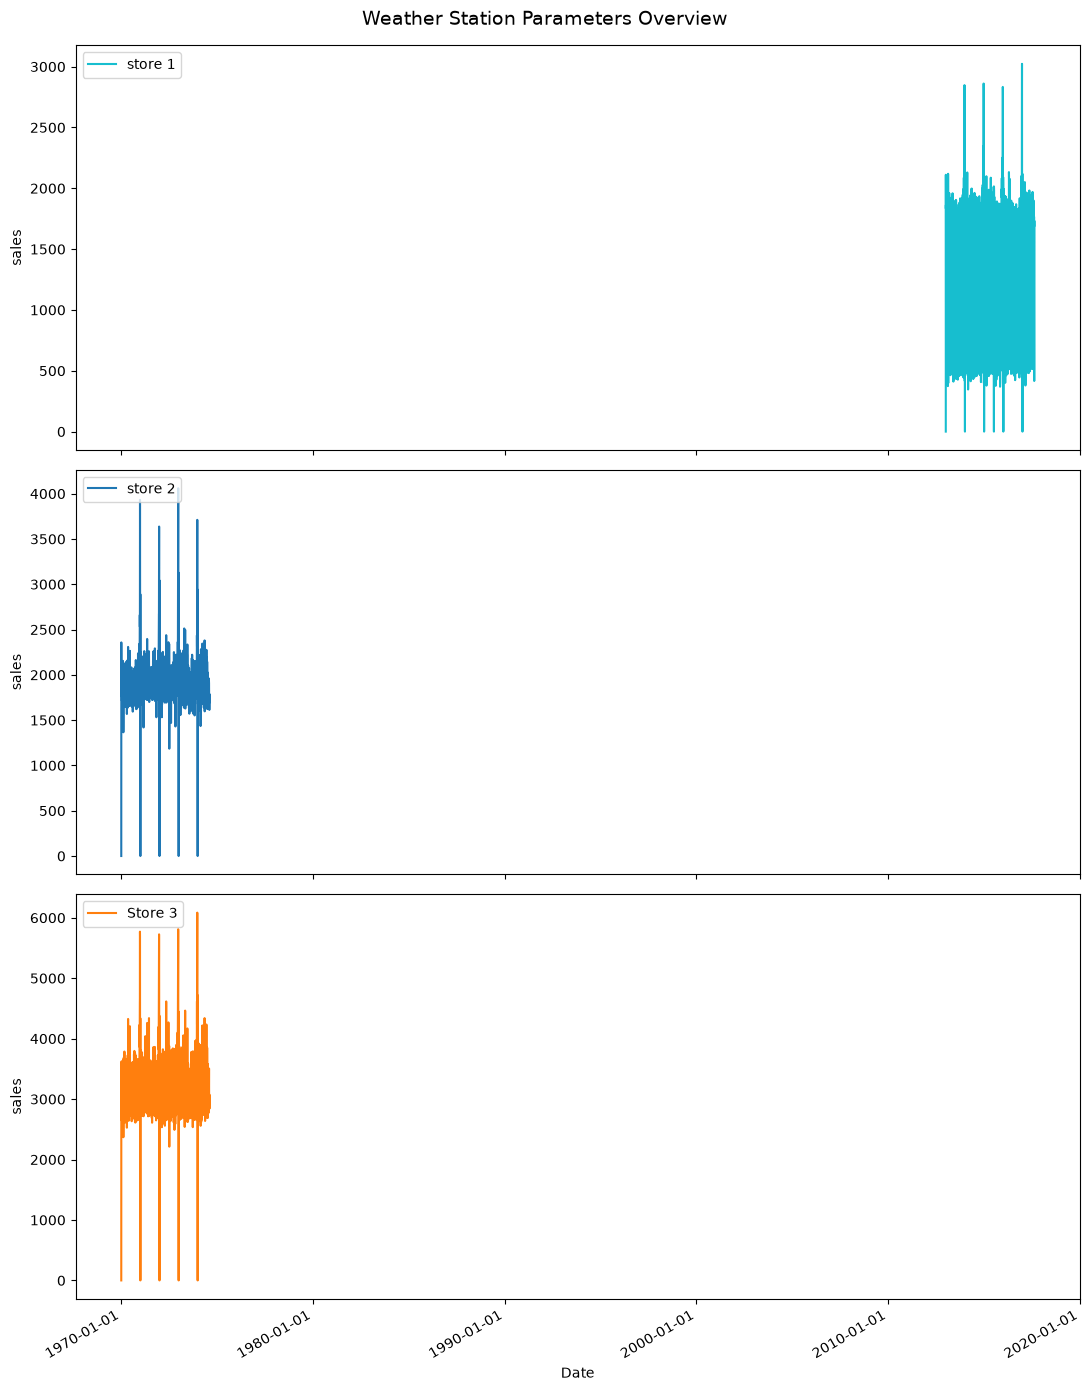

In [30]:
# Create a figure with 6 stacked subplots
fig, axes = plt.subplots(3, 1, figsize=(11, 14), sharex=True)

# 1. Air Temperatures
# The issue is that when you do df.set_index('date'), the index is "date", but you refer to df.axes[0] (same as df.index).
# However, if you modify the DataFrame after setting the index (like with .reset_index() or changing the index), or if you want to ensure date formatting,
# using df.index as the x value is best. Also, if your index is not datetime, matplotlib might not format the x-axis as dates.
# This version below ensures plotting with a datetime index as x, and adds automatic date formatting.
axes[0].plot(df.index, df["1"], color="tab:cyan", label="store 1")
axes[0].set_ylabel("sales")
axes[0].set_xlabel("date")

import matplotlib.dates as mdates
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()  # Auto-rotates the dates for all subplots for better readability

axes[0].legend(loc="upper left")

axes[1].plot(y_Ta_200, color="tab:blue", label="store 2")
axes[1].set_ylabel("sales")
axes[1].legend(loc="upper left")

# 2. Soil Temperatures
axes[2].plot(y_ST_10, color="tab:orange", label="Store 3")
axes[2].set_ylabel("sales")
axes[2].legend(loc="upper left")

# axes[3].plot(y_ST_200, color='tab:brown', label='Soil Temp 20cm (Ts_20)')
# axes[3].set_ylabel('°C')
# axes[3].legend(loc='upper left')

# # 3. Soil Moistures
# axes[4].plot(y_SM_10, color='tab:green', label='Soil Moisture 10cm (SM_10)')
# axes[4].set_ylabel('% / m³')
# axes[4].legend(loc='upper left')

# axes[5].plot(y_SM_20, color='tab:olive', label='Soil Moisture 20cm (SM_20)')
# axes[5].set_ylabel('% / m³')
# axes[5].legend(loc='upper left')

plt.xlabel("Date")
plt.suptitle("Weather Station Parameters Overview", fontsize=14, y=0.99)
plt.tight_layout()
plt.show()

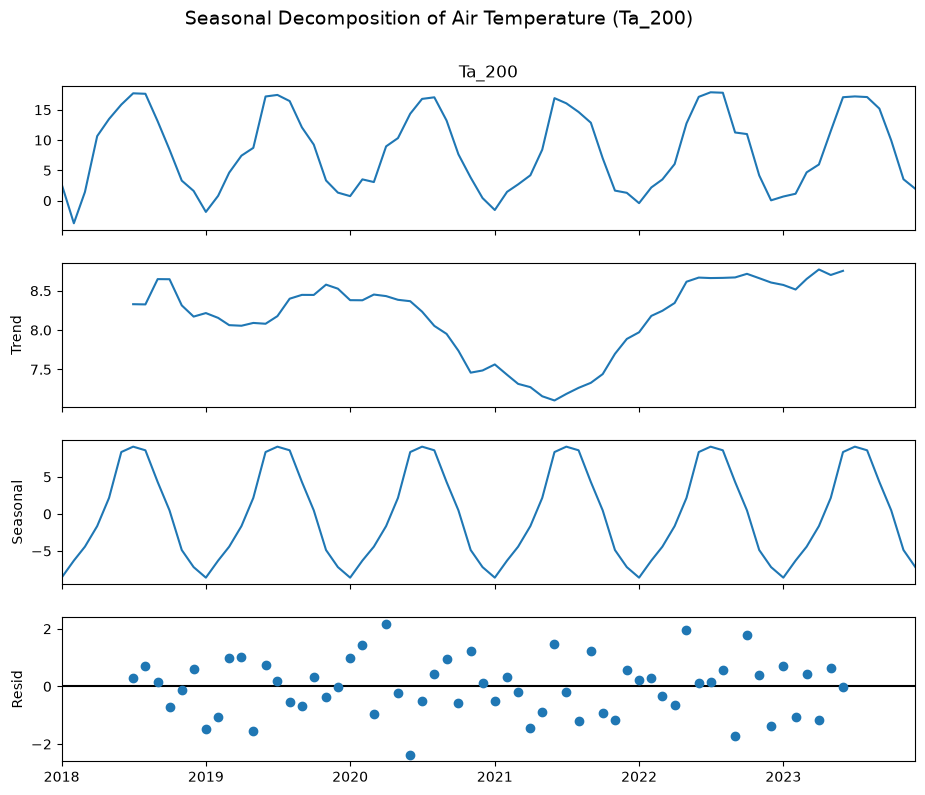

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp_Ta_200 = seasonal_decompose(y_Ta_200, model='additive', period=12)

# Plot the 4 components: Observed, Trend, Seasonal, Residuals
fig = decomp_Ta_200.plot()
fig.set_size_inches(10, 8)
fig.suptitle('Seasonal Decomposition of Air Temperature at 2 meters', fontsize=14, y=1.02)

# Label y-axis 
axes = fig.get_axes()
axes[0].set_ylabel("Observed (°C)")
axes[1].set_ylabel("Trend (°C)")
axes[2].set_ylabel("Seasonal (°C offset)")
axes[3].set_ylabel("Residual (°C error)")
plt.show()

In [ ]:
decomp_ST_20 = seasonal_decompose(y_ST_20, model='additive', period=12)

# Plot the 4 components: Observed, Trend, Seasonal, Residuals
fig = decomp_ST_20.plot()
fig.set_size_inches(10, 8)
fig.suptitle('Seasonal Decomposition of Air Temperature (ST_20)', fontsize=14, y=1.02)

# Label y-axis 
axes = fig.get_axes()
axes[0].set_ylabel("Observed (°C)")
axes[1].set_ylabel("Trend (°C)")
axes[2].set_ylabel("Seasonal (°C offset)")
axes[3].set_ylabel("Residual (°C error)")
plt.show()